<a href="https://colab.research.google.com/github/richard-alcala-code/AIOMovie/blob/develop/notebooks/AIO_Movie_Core_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Deep Learning | Proyecto Final - AIOMovie (Sistema de Recomendación de Películas)**
<br>
Un modelo de aprendizaje profundo que aprende las preferencias ocultas de los usuarios y las películas a partir de miles de valoraciones, sin necesidad de saber nada sobre el contenido de la película.

<br>
--- Richard Alcala Cuba


## Objetivo


El objetivo de este proyecto es que cada estudiante aplique, de forma individual, los conceptos y técnicas de Deep Learning trabajados durante el curso para resolver un problema real en un dominio de su elección, ya sea entrenando un modelo desde cero, o adaptando/ajustando (transfer learning o fine-tuning) un modelo ya existente, reflejando cómo se trabaja hoy en la práctica profesional.

## 1. Selección del dominio del Problema


*   **Dominio:** Sistemas de Recomendación.
*   **Problema específico:** Recomendar películas similares a una dada, usando embeddings de un modelo de deep learning entrenado con datos de MovieLens.

## 2. Recopilación de Datos

*   **Dataset Escogido:** Dataset público de [MovieLens](https://grouplens.org/datasets/movielens/) (`ml-latest-small.zip`) (movies.csv, links.csv, ratings.csv) obtenido de fuente curada. Este dataset es apropiado por su tamaño manejable y su representatividad para un proyecto académico. Se complementa con TMDB para metadata (posters, sinopsis).

## 3. Diseño del Modelo



**Enfoque elegido:** Se eligió Neural Collaborative Filtering (NCF) como arquitectura, implementando sus tres niveles de complejidad progresiva:

* GMF (Generalized Matrix Factorization)
* MLP (Multi-Layer Perceptron)
* NeuMF NeuMF (Neural Matrix Factorization)

<br>

**Función de pérdida (Loss Function):** MSE (Mean Squared Error)

**Algoritmo de optimización:** Adam (Adaptive Moment Estimation)

## 4. Implementacion del modelo

**a. Carga y Configuración Inicial del Dataset MovieLens**

In [ ]:
import pandas as pd
import zipfile
import requests
import io

# Define the URL for the MovieLens dataset (ml-latest-small.zip)
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"

# Send an HTTP GET request to download the zip file content
response = requests.get(url)

# Open the downloaded content as a zip file in memory and extract all its contents
# to the '/content/' directory in the Colab environment.
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("/content/")

# Define the base path where the extracted files are located
base_path = "/content/ml-latest-small/"

# Construct the full file paths for movies.csv, links.csv, and ratings.csv
path_movies = base_path + "movies.csv"
path_links = base_path + "links.csv"
path_ratings = base_path + "ratings.csv"

try:
    # Load all necessary datasets into pandas DataFrames
    movies = pd.read_csv(path_movies)
    links = pd.read_csv(path_links)
    ratings = pd.read_csv(path_ratings)

    # Merge them to create a complete training dataset
    # First, merge ratings with links to get 'userId' and 'tmdbId' together
    movie_data = pd.merge(ratings, links, on='movieId')

    # Then, merge with the 'movies' DataFrame to add movie titles
    movie_data = pd.merge(movie_data, movies[['movieId', 'title']], on='movieId')

    print(f"Dataset loaded successfully with {movie_data.shape} rating records.")
    print(f"Columns now available: {movie_data.columns.tolist()}")

except FileNotFoundError:
    print("Error: Ensure movies.csv, links.csv, and ratings.csv are available.")

Dataset loaded successfully with (100836, 7) rating records.
Columns now available: ['userId', 'movieId', 'rating', 'timestamp', 'imdbId', 'tmdbId', 'title']


**b. Funciones Auxiliares y Mapeos para Recomendaciones**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Create a mapping from tmdbId to title for efficient title retrieval.
tmdb_id_to_title_map_df = pd.merge(movies[['movieId', 'title']], links[['movieId', 'tmdbId']], on='movieId', how='inner')
tmdb_id_to_title_map = tmdb_id_to_title_map_df.drop_duplicates(subset=['tmdbId']).set_index('tmdbId')['title'].to_dict()

def get_movie_info_by_title(title_substring, movies_df, movie_data_df):
    """
    Searches for a movie by a substring of its title (case-insensitive)
    and returns its tmdbId and the exact found title.
    Uses movies_df for initial title search and movie_data_df to link to tmdbId.
    """
    # Search in the original 'movies' DataFrame for a clean title match
    matching_movies_in_movies = movies_df[movies_df['title'].str.contains(title_substring, case=False, na=False, regex=False)]

    if not matching_movies_in_movies.empty:
        # Get the movieId and exact title from the first match in 'movies'
        matched_movie_id = matching_movies_in_movies.iloc[0]['movieId']
        exact_found_title = matching_movies_in_movies.iloc[0]['title']

        # Now, find the corresponding tmdbId from the 'movie_data' DataFrame
        # which contains the movieId-tmdbId mapping
        tmdb_id_row = movie_data_df[movie_data_df['movieId'] == matched_movie_id]
        if not tmdb_id_row.empty:
            tmdb_id = tmdb_id_row.iloc[0]['tmdbId']
            return tmdb_id, exact_found_title
    return None, None

def recommend_movies_based_on_movie(input_movie_title, model, movie2movie_encoded, movies_df, tmdb_id_to_title_map, top_n=10, embedding_layer_name='movie_embedding'):
    """
    Generates movie recommendations based on a given movie title using movie embeddings.
    """
    target_tmdb_id, found_title = get_movie_info_by_title(input_movie_title, movies_df, movie_data) # Pass movie_data here
    if target_tmdb_id is None:
        print(f"Movie '{input_movie_title}' not found in the dataset.")
        return []

    target_movie_encoded = movie2movie_encoded.get(target_tmdb_id)
    if target_movie_encoded is None:
        print(f"Encoded ID for '{found_title}' (TMDB ID: {target_tmdb_id}) not found. This movie might not be in the training data.")
        return []

    # Get the movie embedding layer from the trained model using the specified name
    # Handle cases where the layer might be named differently in different models
    try:
        movie_embedding_layer = model.get_layer(embedding_layer_name)
    except ValueError:
        print(f"Error: Embedding layer '{embedding_layer_name}' not found in the model. Please check the layer name.")
        return []

    movie_embeddings = movie_embedding_layer.get_weights()[0] # Shape: (num_movies, embedding_size)

    # Get the embedding of the target movie
    if target_movie_encoded >= len(movie_embeddings):
        print(f"Error: Encoded ID {target_movie_encoded} for '{found_title}' is out of bounds for movie embeddings.")
        return []
    target_movie_embedding = movie_embeddings[target_movie_encoded]

    # Calculate cosine similarity with all other movie embeddings
    similarities = cosine_similarity(target_movie_embedding.reshape(1, -1), movie_embeddings).flatten()

    # Get the indices of the most similar movies (excluding the movie itself)
    # argsort returns indices that would sort an array; [::-1] reverses for descending order
    # [1:top_n+1] slices to get top N, excluding the first one (which is the movie itself)
    top_similar_encoded_indices = similarities.argsort()[::-1][1:top_n+1]

    recommended_titles = []
    # Create a reverse mapping from encoded_id to tmdb_id
    movie_encoded_to_tmdb = {v: k for k, v in movie2movie_encoded.items()}

    for encoded_idx in top_similar_encoded_indices:
        recommended_tmdb_id = movie_encoded_to_tmdb.get(encoded_idx)
        if recommended_tmdb_id is not None:
            # Use the pre-created map for titles
            title = tmdb_id_to_title_map.get(recommended_tmdb_id)
            if title:
                recommended_titles.append(title)

    return recommended_titles

**c. Metadata Integration with TMDB Token**

In [ ]:
import requests
from google.colab import userdata

TMDB_TOKEN = userdata.get('TMDB_TOKEN') # Please refer to https://developer.themoviedb.org/docs/getting-started
BASE_URL = "https://api.themoviedb.org/3/movie/"

def get_movie_metadata(tmdb_id):
    # Ensure tmdb_id is not NaN and can be converted to int
    if pd.isna(tmdb_id):
        return None

    headers = {
        "Authorization": f"Bearer {TMDB_TOKEN}",
        "Content-Type": "application/json;charset=utf-8"
    }
    try:
        # Query TMDB using the ID obtained from MovieLens
        response = requests.get(f"{BASE_URL}{int(tmdb_id)}", headers=headers)
        response.raise_for_status() # Raise an exception for HTTP errors (4xx or 5xx)
        data = response.json()
        return {
            "overview": data.get("overview"),
            "poster_path": f"https://image.tmdb.org/t/p/w500{data.get('poster_path')}"
        }
    except requests.exceptions.RequestException as e:
        print(f"API request failed for TMDB ID {tmdb_id}: {e}")
        return None
    except ValueError as e:
        print(f"Error converting TMDB ID {tmdb_id} to int: {e}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred for TMDB ID {tmdb_id}: {e}")
        return None

# Test example with a movie
# Select the first valid tmdbId for testing
first_tmdb_id = movie_data['tmdbId'].dropna().iloc[0]
test_metadata = get_movie_metadata(first_tmdb_id)

# Check if test_metadata is not None before accessing its elements
if test_metadata:
    print(f"Synopsis: {test_metadata['overview'][:100]}...")
else:
    print(f"Could not retrieve metadata for TMDB ID: {first_tmdb_id}")

Synopsis: Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto ...


**d. Splitting Data into Training and Validation Sets**

To properly evaluate the model's generalization capabilities and prevent overfitting, we will split the `movie_data` into training and validation sets. The training set will be used to train the model, and the validation set will be used to monitor its performance on unseen data during training.

In [ ]:
from sklearn.model_selection import train_test_split

# Split movie_data into training (train_data) and validation (val_data) sets.
# We use an 80/20 split: 80% for the model to learn and 20% to test its performance.
# random_state=42 is a seed that ensures the split is reproducible every time the code runs.
train_data, val_data = train_test_split(movie_data, test_size=0.2, random_state=42)

print(f"Training data shape: {train_data.shape}")
print(f"Validation data shape: {val_data.shape}")

Training data shape: (80668, 7)
Validation data shape: (20168, 7)


In [ ]:
import numpy as np

# --- Data Preparation ---
# Encode IDs to be continuous (0 to N)
user_ids = movie_data["userId"].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
movie_ids = sorted(movie_data["tmdbId"].unique().tolist())
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}

# Apply encoding to training data
train_data["user"] = train_data["userId"].map(user2user_encoded)
train_data["movie"] = train_data["tmdbId"].map(movie2movie_encoded)

# Apply encoding to validation data
val_data["user"] = val_data["userId"].map(user2user_encoded)
val_data["movie"] = val_data["tmdbId"].map(movie2movie_encoded)

**e. NCF (Neural Collaborative Filtering) Implementation**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

## 1. Generalized Matrix Factorization (GMF) Model ##
def build_gmf_model(num_users, num_movies, embedding_size=50):
    # User and movie inputs
    user_input = layers.Input(shape=(1,), name='user_input_gmf')
    movie_input = layers.Input(shape=(1,), name='movie_input_gmf')

    # User and movie embeddings
    user_embedding = layers.Embedding(num_users, embedding_size, name='user_embedding_gmf')(user_input)
    movie_embedding = layers.Embedding(num_movies, embedding_size, name='movie_embedding_gmf')(movie_input)

    # Flatten embeddings
    user_latent = layers.Flatten()(user_embedding)
    movie_latent = layers.Flatten()(movie_embedding)

    # Element-wise product
    gmf_output = layers.Multiply()([user_latent, movie_latent])

    # Output layer - adding sigmoid activation
    prediction = layers.Dense(1, activation='sigmoid', name='gmf_prediction')(gmf_output)

    model = tf.keras.Model(inputs=[user_input, movie_input], outputs=prediction)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

print("GMF model architecture function defined.")

GMF model architecture function defined.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

## 2. Multi-Layer Perceptron (MLP) Model ##
def build_mlp_model(num_users, num_movies, embedding_size=50, layers_config=[64, 32, 16]):
    # User and movie inputs
    user_input = layers.Input(shape=(1,), name='user_input_mlp')
    movie_input = layers.Input(shape=(1,), name='movie_input_mlp')

    # User and movie embeddings
    user_embedding = layers.Embedding(num_users, embedding_size, name='user_embedding_mlp')(user_input)
    movie_embedding = layers.Embedding(num_movies, embedding_size, name='movie_embedding_mlp')(movie_input)

    # Flatten embeddings
    user_latent = layers.Flatten()(user_embedding)
    movie_latent = layers.Flatten()(movie_embedding)

    # Concatenate latent features
    concat_features = layers.Concatenate()([user_latent, movie_latent])

    # MLP layers
    mlp_layer = concat_features
    for i, units in enumerate(layers_config):
        mlp_layer = layers.Dense(units, activation='relu', name=f'mlp_dense_{i}')(mlp_layer)

    # Output layer - adding sigmoid activation
    prediction = layers.Dense(1, activation='sigmoid', name='mlp_prediction')(mlp_layer)

    model = tf.keras.Model(inputs=[user_input, movie_input], outputs=prediction)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

print("MLP model architecture function defined.")

MLP model architecture function defined.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

## 3. Neural Matrix Factorization (NeuMF) Model ##
def build_neumf_model(num_users, num_movies, gmf_embedding_size=50, mlp_embedding_size=50, mlp_layers_config=[64, 32, 16]):
    # GMF Path
    user_input_gmf = layers.Input(shape=(1,), name='user_input_neumf_gmf')
    movie_input_gmf = layers.Input(shape=(1,), name='movie_input_neumf_gmf')
    user_embedding_gmf = layers.Embedding(num_users, gmf_embedding_size, name='user_embedding_neumf_gmf')(user_input_gmf)
    movie_embedding_gmf = layers.Embedding(num_movies, gmf_embedding_size, name='movie_embedding_neumf_gmf')(movie_input_gmf)
    user_latent_gmf = layers.Flatten()(user_embedding_gmf)
    movie_latent_gmf = layers.Flatten()(movie_embedding_gmf)
    gmf_output = layers.Multiply()([user_latent_gmf, movie_latent_gmf])

    # MLP Path
    user_input_mlp = layers.Input(shape=(1,), name='user_input_neumf_mlp')
    movie_input_mlp = layers.Input(shape=(1,), name='movie_input_neumf_mlp')
    user_embedding_mlp = layers.Embedding(num_users, mlp_embedding_size, name='user_embedding_neumf_mlp')(user_input_mlp)
    movie_embedding_mlp = layers.Embedding(num_movies, mlp_embedding_size, name='movie_embedding_neumf_mlp')(movie_input_mlp)
    user_latent_mlp = layers.Flatten()(user_embedding_mlp)
    movie_latent_mlp = layers.Flatten()(movie_embedding_mlp)
    concat_features_mlp = layers.Concatenate()([user_latent_mlp, movie_latent_mlp])

    mlp_output = concat_features_mlp
    for i, units in enumerate(mlp_layers_config):
        mlp_output = layers.Dense(units, activation='relu', name=f'neumf_mlp_dense_{i}')(mlp_output)

    # Concatenate GMF and MLP outputs
    neumf_concat = layers.Concatenate()([gmf_output, mlp_output])

    # Final output layer - adding sigmoid activation
    prediction = layers.Dense(1, activation='sigmoid', name='neumf_prediction')(neumf_concat)

    model = tf.keras.Model(inputs=[user_input_gmf, movie_input_gmf, user_input_mlp, movie_input_mlp], outputs=prediction)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

print("NeuMF model architecture function defined.")

NeuMF model architecture function defined.


## 5. Entrenamiento y ajuste de parámetros

**5.1 Training Models**

In [ ]:
# Build and train the GMF model
gmf_model = build_gmf_model(len(user_ids), len(movie_ids))
print("Training GMF model...")
gmf_model.fit(
    x=[train_data["user"], train_data["movie"]],
    y=train_data["rating"],
    batch_size=64,
    epochs=5,
    validation_data=([val_data["user"], val_data["movie"]], val_data["rating"])
)

# Save the GMF model
gmf_model.save('aiomovie_ncf_gmf.keras')
print("GMF model saved as 'aiomovie_ncf_gmf.keras'.")

Training GMF model...
Epoch 1/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 8.7995 - val_loss: 7.5761
Epoch 2/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.4340 - val_loss: 7.4103
Epoch 3/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.3583 - val_loss: 7.3950
Epoch 4/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 7.3491 - val_loss: 7.3914
Epoch 5/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.3472 - val_loss: 7.3899
GMF model saved as 'aiomovie_ncf_gmf.keras'.


In [ ]:
# Build and train the MLP model
mlp_model = build_mlp_model(len(user_ids), len(movie_ids))
print("Training MLP model...")
mlp_model.fit(
    x=[train_data["user"], train_data["movie"]],
    y=train_data["rating"],
    batch_size=64,
    epochs=5,
    validation_data=([val_data["user"], val_data["movie"]], val_data["rating"])
)

# Save the MLP model
mlp_model.save('aiomovie_ncf_mlp.keras')
print("MLP model saved as 'aiomovie_ncf_mlp.keras'.")

Training MLP model...
Epoch 1/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 7.4546 - val_loss: 7.3375
Epoch 2/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.3464 - val_loss: 7.3375
Epoch 3/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.3464 - val_loss: 7.3375
Epoch 4/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 7.3464 - val_loss: 7.3375
Epoch 5/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.3464 - val_loss: 7.3376
MLP model saved as 'aiomovie_ncf_mlp.keras'.


In [ ]:
# Build and train the NeuMF model
neumf_model = build_neumf_model(len(user_ids), len(movie_ids))
print("Training NeuMF model...")
neumf_model.fit(
    x=[train_data["user"], train_data["movie"], train_data["user"], train_data["movie"]],
    y=train_data["rating"],
    batch_size=64,
    epochs=5,
    validation_data=(
        [val_data["user"], val_data["movie"], val_data["user"], val_data["movie"]],
        val_data["rating"]
    )
)

# Save the NeuMF model
neumf_model.save('aiomovie_ncf_neumf.keras')
print("NeuMF model saved as 'aiomovie_ncf_neumf.keras'.")

Training NeuMF model...
Epoch 1/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 7.4442 - val_loss: 7.3375
Epoch 2/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 7.3464 - val_loss: 7.3375
Epoch 3/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 7.3464 - val_loss: 7.3375
Epoch 4/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.3464 - val_loss: 7.3376
Epoch 5/5
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 7.3464 - val_loss: 7.3376
NeuMF model saved as 'aiomovie_ncf_neumf.keras'.


**5.2 Testing Models**

In [ ]:
# Testing the GMF model
movie_to_search_gmf = "Toy Story"
recommended_movies_gmf = recommend_movies_based_on_movie(
    movie_to_search_gmf,
    gmf_model,
    movie2movie_encoded,
    movies,
    tmdb_id_to_title_map,
    top_n=10,
    embedding_layer_name='movie_embedding_gmf'
)

if recommended_movies_gmf:
    print(f"\nTop 10 recommendations for '{movie_to_search_gmf}' (using GMF model):")
    for i, title in enumerate(recommended_movies_gmf):
        print(f"{i+1}. {title}")
else:
    print(f"\nNo recommendations could be generated for '{movie_to_search_gmf}' using the GMF model.")


Top 10 recommendations for 'Toy Story' (using GMF model):
1. Seven (a.k.a. Se7en) (1995)
2. Pulp Fiction (1994)
3. Shawshank Redemption, The (1994)
4. Silence of the Lambs, The (1991)
5. Terminator 2: Judgment Day (1991)
6. Usual Suspects, The (1995)
7. Independence Day (a.k.a. ID4) (1996)
8. Braveheart (1995)
9. Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
10. Happy Gilmore (1996)


In [ ]:
# Testing the MLP model
movie_to_search_mlp = "Toy Story"
recommended_movies_mlp = recommend_movies_based_on_movie(
    movie_to_search_mlp,
    mlp_model,
    movie2movie_encoded,
    movies,
    tmdb_id_to_title_map,
    top_n=10,
    embedding_layer_name='movie_embedding_mlp'
)

if recommended_movies_mlp:
    print(f"\nTop 10 recommendations for '{movie_to_search_mlp}' (using MLP model):")
    for i, title in enumerate(recommended_movies_mlp):
        print(f"{i+1}. {title}")
else:
    print(f"\nNo recommendations could be generated for '{movie_to_search_mlp}' using the MLP model.")


Top 10 recommendations for 'Toy Story' (using MLP model):
1. Doors, The (1991)
2. Geronimo: An American Legend (1993)
3. Leaving Las Vegas (1995)
4. Shaun the Sheep Movie (2015)
5. Gintama: The Final Chapter - Be Forever Yorozuya (2013)
6. About Schmidt (2002)
7. Ocean's Thirteen (2007)
8. Star Wars: Episode I - The Phantom Menace (1999)
9. How to Deal (2003)
10. Sure Thing, The (1985)


In [ ]:
# Testing the NeuMF model
movie_to_search_neumf = "Toy Story"
recommended_movies_neumf = recommend_movies_based_on_movie(
    movie_to_search_neumf,
    neumf_model,
    movie2movie_encoded,
    movies,
    tmdb_id_to_title_map,
    top_n=10,
    embedding_layer_name='movie_embedding_neumf_mlp'
)

if recommended_movies_neumf:
    print(f"\nTop 10 recommendations for '{movie_to_search_neumf}' (using NeuMF model):")
    for i, title in enumerate(recommended_movies_neumf):
        print(f"{i+1}. {title}")
else:
    print(f"\nNo recommendations could be generated for '{movie_to_search_neumf}' using the NeuMF model.")


Top 10 recommendations for 'Toy Story' (using NeuMF model):
1. Persuasion (1995)
2. Punch-Drunk Love (2002)
3. Gladiator (1992)
4. Bounty Hunter, The (2010)
5. Balto (1995)
6. Runaway Jury (2003)
7. Blazing Saddles (1974)
8. Twilight Saga: Eclipse, The (2010)
9. In the Cut (2003)
10. London Has Fallen (2016)


## 6. Evaluación y resultados

**a. Evaluar la pérdida de validación de cada modelo**

In [ ]:
import tensorflow as tf
import os

# Define the paths to the saved models
model_paths = {
    'GMF Model': 'aiomovie_ncf_gmf.keras',
    'MLP Model': 'aiomovie_ncf_mlp.keras',
    'NeuMF Model': 'aiomovie_ncf_neumf.keras'
}

# Prepare validation data for evaluation
# The NeuMF model requires user and movie inputs to be passed twice
val_x_neumf = [val_data["user"], val_data["movie"], val_data["user"], val_data["movie"]]

# Dictionary to store dynamic validation losses
dynamic_validation_losses = {}

print("Evaluating validation loss for each model:")

for model_name, path in model_paths.items():
    if os.path.exists(path):
        try:
            model = tf.keras.models.load_model(path)
            # Re-compile the model to ensure 'loss' metric is available for evaluate
            model.compile(optimizer='adam', loss='mean_squared_error')

            # Determine the correct input format for evaluation
            if model_name == 'NeuMF Model':
                val_loss = model.evaluate(val_x_neumf, val_data["rating"], verbose=0)
            else:
                val_loss = model.evaluate([val_data["user"], val_data["movie"]], val_data["rating"], verbose=0)

            dynamic_validation_losses[model_name] = val_loss # Store the loss dynamically
            print(f"  {model_name}: Validation Loss = {val_loss:.4f}")
        except Exception as e:
            print(f"  Error evaluating {model_name} from '{path}': {e}")
    else:
        print(f"  {model_name}: Model file not found at '{path}'.")

print("\nValidation losses stored dynamically.")

Evaluating validation loss for each model:
  GMF Model: Validation Loss = 7.3899
  MLP Model: Validation Loss = 7.3376
  NeuMF Model: Validation Loss = 7.3376

Validation losses stored dynamically.


**b. Comparación Visual de la Pérdida de Validación**

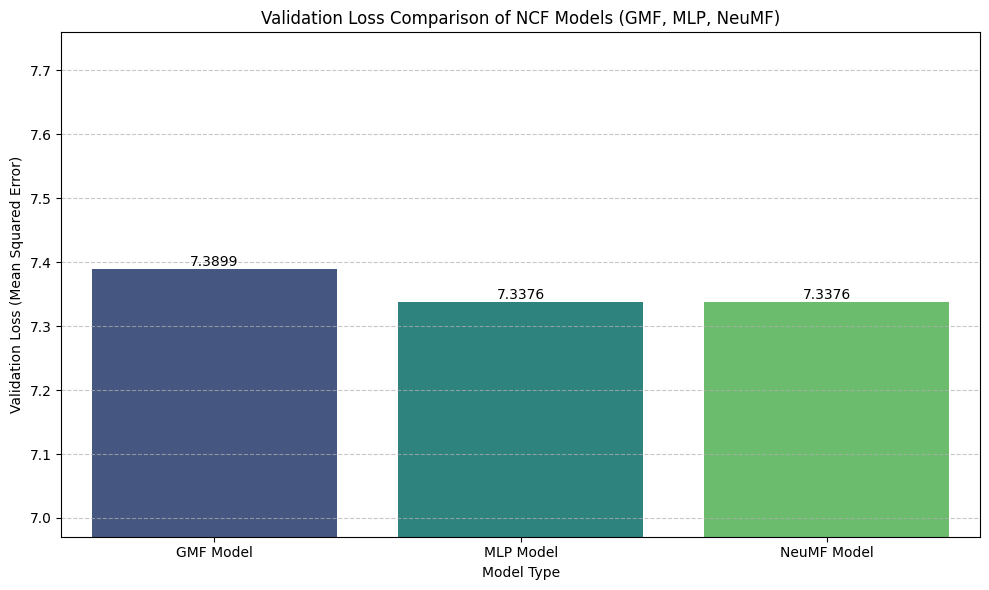

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the dynamically stored validation losses
# Ensure that dynamic_validation_losses has been populated by running the previous cell.
if 'dynamic_validation_losses' in locals() and dynamic_validation_losses:
    losses_df = pd.DataFrame(dynamic_validation_losses.items(), columns=['Model', 'Validation Loss'])

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Model', y='Validation Loss', data=losses_df, palette='viridis', hue='Model', legend=False)
    plt.title('Validation Loss Comparison of NCF Models (GMF, MLP, NeuMF)')
    plt.xlabel('Model Type')
    plt.ylabel('Validation Loss (Mean Squared Error)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(min(losses_df['Validation Loss']) * 0.95, max(losses_df['Validation Loss']) * 1.05) # Adjust y-axis limits for better visualization

    # Add the loss values on top of the bars
    for index, row in losses_df.iterrows():
        plt.text(index, row['Validation Loss'], f"{row['Validation Loss']:.4f}", color='black', ha="center", va='bottom')

    plt.tight_layout()
    plt.show()
else:
    print("dynamic_validation_losses is empty or not defined. Please run the evaluation cell first.")

**c. Visualización de Calificaciones Reales vs. Predichas (Modelo NeuMF)**

631/631 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


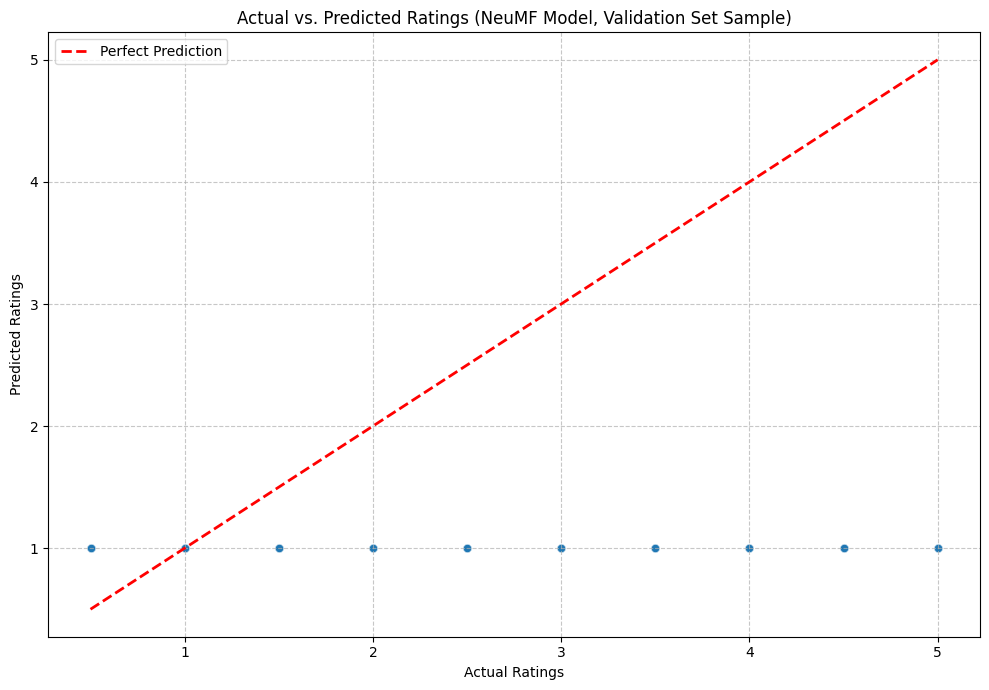

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the NeuMF model
neumf_model = tf.keras.models.load_model('aiomovie_ncf_neumf.keras')

# Make predictions on the validation set using the NeuMF model
# The NeuMF model requires user and movie inputs to be passed twice
val_x_neumf_pred = [val_data["user"], val_data["movie"], val_data["user"], val_data["movie"]]
predicted_ratings_neumf = neumf_model.predict(val_x_neumf_pred).flatten()

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Actual Ratings': val_data["rating"].values,
    'Predicted Ratings': predicted_ratings_neumf
})

# Sample a subset for better visualization if the dataset is too large
# Here, we'll take a random sample of 1000 points
if len(plot_df) > 1000:
    plot_df_sample = plot_df.sample(n=1000, random_state=42)
else:
    plot_df_sample = plot_df

# Create the scatter plot
fig = plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Ratings', y='Predicted Ratings', data=plot_df_sample, alpha=0.6)

# Add a diagonal line for perfect predictions
min_rating = plot_df_sample['Actual Ratings'].min()
max_rating = plot_df_sample['Actual Ratings'].max()
plt.plot([min_rating, max_rating], [min_rating, max_rating], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Ratings (NeuMF Model, Validation Set Sample)')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()